# Function 1

This function is described by 2 input features, each of which are nomalised to lie within the range 0 and 1. The optimisation goal is to maximise the output value. The function describes the radiation from contamination sources in a two-dimensional area. Proximity to a source yields a non-zero reading. The initial data set consists of 10 data points.

## Summary
Given that the output values are several orders of magntiude apart, it has been challenging to find a model that describes the underlying function. The most promising method has been Bayesian Optimisation with two Gaussian Process surrogate models: the first, a classification model trained on the observerd negative and positive outputs that gives a probability that a point will yield a positive value; and the second, a regression model that is trained on all positive outputs. The observed data points are too few to only train in promising regions, so both models have been trained globally. However, rather than rely on a global acquisition function to select the next point, generating candidate points in the vicinity of the current best observed point has showed promise. Candidates are those equidistant along the circumference of a circle around the best observed point with radius equal to the midpoint between the best observed point and the nearest negative point.

## Week 1 - Initial exploration

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid, get_farthest_point

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=1, week=1)

print(f"Mean = {y.mean()}")
print(f"Standard deviation = {y.std()}")

print(f"Minimum = {y.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(y, quantile)}")
print(f"Maximum = {y.max()}")

Mean = -0.00036060626443627054
Standard deviation = 0.0010818187933090686
Minimum = -0.0036060626443634764
25.0% quantile = -1.566819952674063e-91
50.0% quantile = 6.79372375723414e-80
75.0% quantile = 7.903833193127448e-47
Maximum = 7.710875114502849e-16


Initial exploratory data analysis reveals very small output values. The minimum output value is negative, and there are quite a few points with negative values. The absolute value of the minimum is approximately 13 orders of magnitude larger than the maximum. The minimum dominates the mean, and the median is a more useful measure of the average.

Given that the output values are several orders of magnitude apart, it may be worth considering a logarithmic rather than linear scale. However, a decision would need to be made on what to do with the negative outputs. Given that they form a significant proportion of the known data points, we would lose quite a lot of potentially useful information by dropping them.

As there are a relatively small number of observed data points and given the limited number of queries we can submit, we apply Bayesian Optimisation. We fit a Gaussian Process surrogate model to the data, allowing us to model the underlying function and its associated uncertainty. A Radial Basis Function (RBF) kernel is chosen initially, and it is assumed at this stage that both features are of equal importance and therefore the length scales are fixed at 0.1.

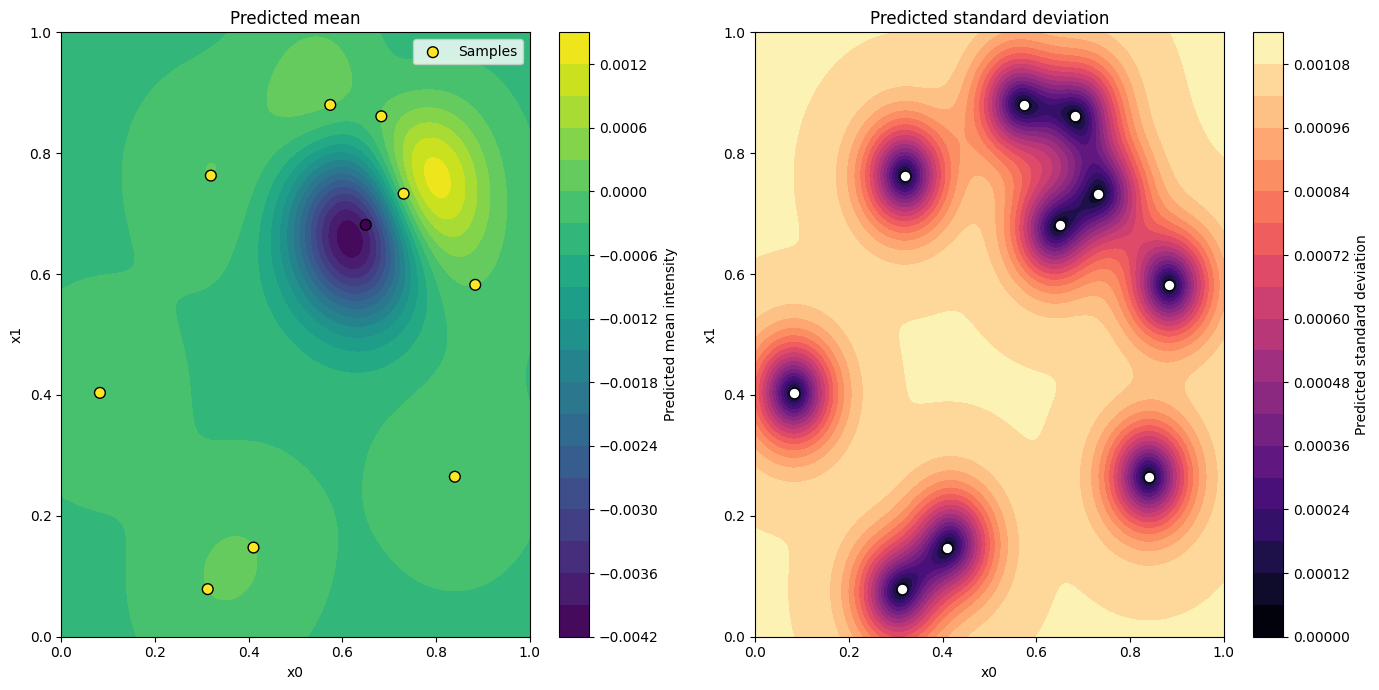

In [3]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

From the contour plot, there appears to be a promising region at around (0.8, 0.8). However, the current maximum value is so small that it is unsure whether this is even an indication of a peak. It could be the case that all observed data points lie in the noise. Therefore, it may be a good idea to query the point of highest uncertainty. This can be done by ignoring the mean and performing a grid search to find the point with the highest standard deviation.

In [4]:
# Use standard deviation as acquisition function for pure exploration
max_idx = np.unravel_index(np.argmax(Y_std), Y_std.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using pure exploration acquisition function = {x_next}")

Proposed point using pure exploration acquisition function = [0. 1.]


This point is found to lie in one of the corners, and little information would be gained here. We could move a bit closer to the centre and query the point (0.05, 0.95). If we assume that all observed data points lie in the noise, it may be worth simply ignoring the Gaussian Process surrogate model for now and finding a point that lies farthest from any observed data points and corners.

In [5]:
# Find farthest point on grid from any corners or samples
x_next = get_farthest_point(X, n_dimensions, grd_res)
print(f"Farthest point on grid from any corners or samples = {x_next}")

Farthest point on grid from any corners or samples = [0.421 0.464]


## Week 2 - A new minimum!

In [6]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid, get_farthest_point

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [7]:
X, y = get_current_weeks_points(function_id=1, week=2)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.421 0.464] yields -0.007205629781049314


The result from last week's query is a new minimum! However, we are still in the exploratory stage and with this result we can eliminate a significantly large area with the Gaussian Process surrogate model:

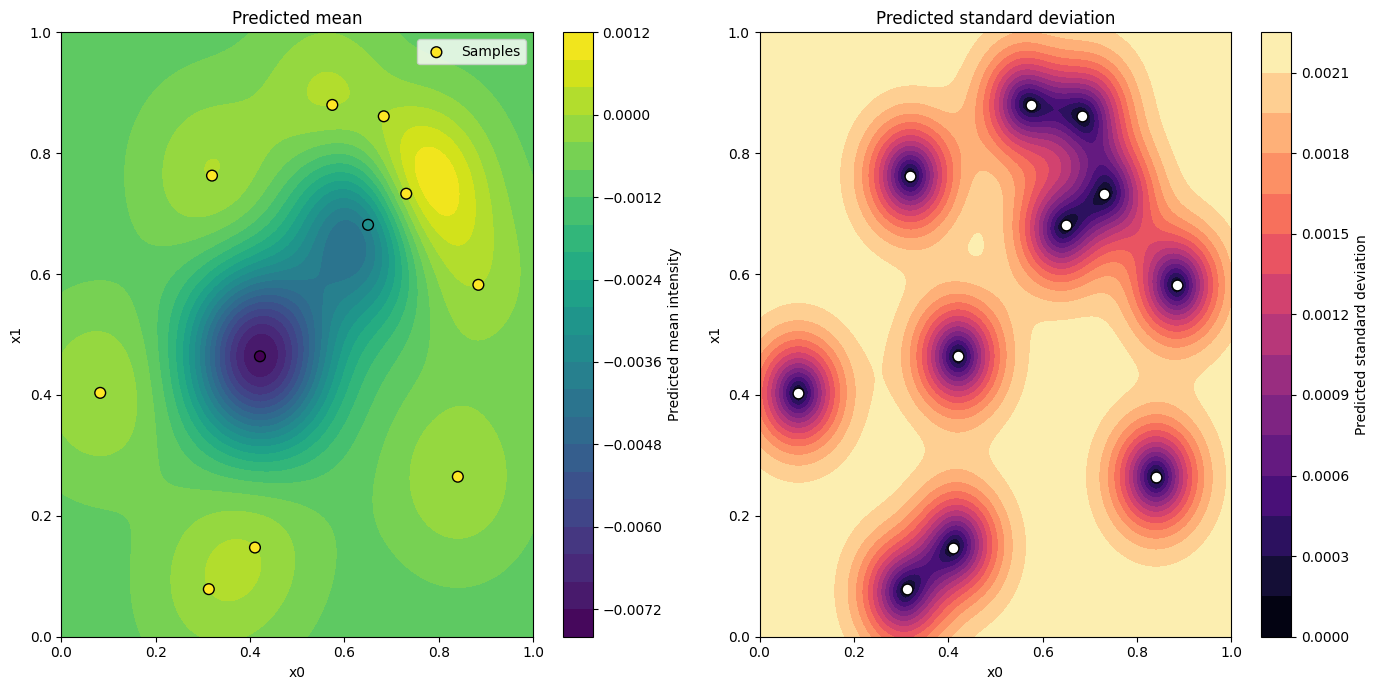

In [8]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

The region around (0.8, 0.8) looks even more promising. However, the predicted mean intensity here is still rather low. It could be that the output values are small, and therefore my previous assumption that the observed data points are just noise is false. Having said that, we have the time to query other regions of space before testing this region.

In [9]:
# Use standard deviation as acquisition function for pure exploration
max_idx = np.unravel_index(np.argmax(Y_std), Y_std.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using pure exploration acquisition function = {x_next}")

Proposed point using pure exploration acquisition function = [0. 1.]


Again, the point where the model is least certain lies in the corner. Rather than query this point, we can find the point that lies farthest from the corners or observed data points:

In [10]:
# Find farthest point on grid from any corners or samples
x_next = get_farthest_point(X, n_dimensions, grd_res)
print(f"Farthest point on grid from any corners or samples = {x_next}")

Farthest point on grid from any corners or samples = [0.682 0.   ]


This lies on a boundary rather than in a corner. Of the two candidates we have identified, it is the one likely to yield more information.

## Week 3 - Exploring a promising region

In [11]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid, get_farthest_point

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [12]:
X, y = get_current_weeks_points(function_id=1, week=3)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.682 0.   ] yields 5.596684327963654e-172


Last week's query yields a positive output, albeit many orders of magntiude smaller than the current best observed point.

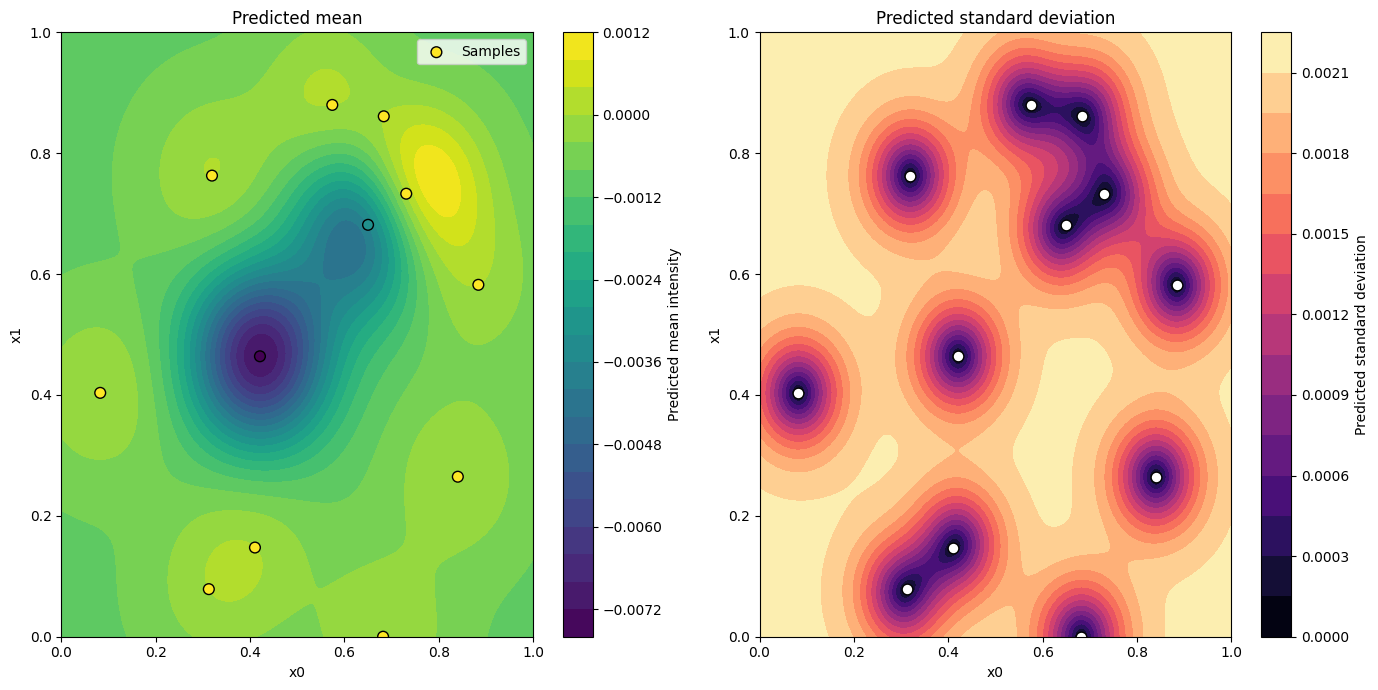

In [13]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

Again, the model identifies an area around (0.8, 0.8) as promising. As we still have some time, and there has been no significant breakthrough, we can take a look at some other candidates before we explore this region.

In [14]:
# Use standard deviation as acquisition function for pure exploration
max_idx = np.unravel_index(np.argmax(Y_std), Y_std.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using pure exploration acquisition function = {x_next}")

# Find farthest point on grid from any corners or samples
x_next = get_farthest_point(X, n_dimensions, grd_res)
print(f"Farthest point on grid from any corners or samples = {x_next}")

Proposed point using pure exploration acquisition function = [0. 1.]
Farthest point on grid from any corners or samples = [0.    0.696]


Using the same aquisition functions as we have in previous weeks, we get candidates to query that are close to the boundaries. The algorithm to find the farthest point from any corners or observed data points yields a point that is the mirror image of last week's query.

In [15]:
# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.unravel_index(np.argmax(acquisition.ucb(Y_mean, Y_std, k=1.96)), Y_mean.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.856 0.772]


The Upper Confidence Bound (UCB) acquisition function with exploration parameter k = 1.96, which corresponds to 95% confidence interval, suggests querying a point that lies close to the promising region identified by the Gaussian Process surrogate model. It also lies sufficiently far away from any boundaries, so this is the next point that should be queried.

## Week 4 - Attempting to fit linear regression models

In [16]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.linear_regression import get_lr_models, kfoldcv, loocv
from bbo.plotting import plot_2d_gp_surfaces, plot_correlation_matrix
from bbo.stats import get_baseline_rmse, get_baseline_mse
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [17]:
X, y = get_current_weeks_points(function_id=1, week=4)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.856 0.772] yields -9.061632524598372e-51


The promising region may not be that promising after all as last week's query yields a negative output. This could be because the RBF kernel is too smooth and a Matern kernel may be better. For now, however, I do not feel there is enough information to make that decision, and therefore we should stick with the RBF kernel.

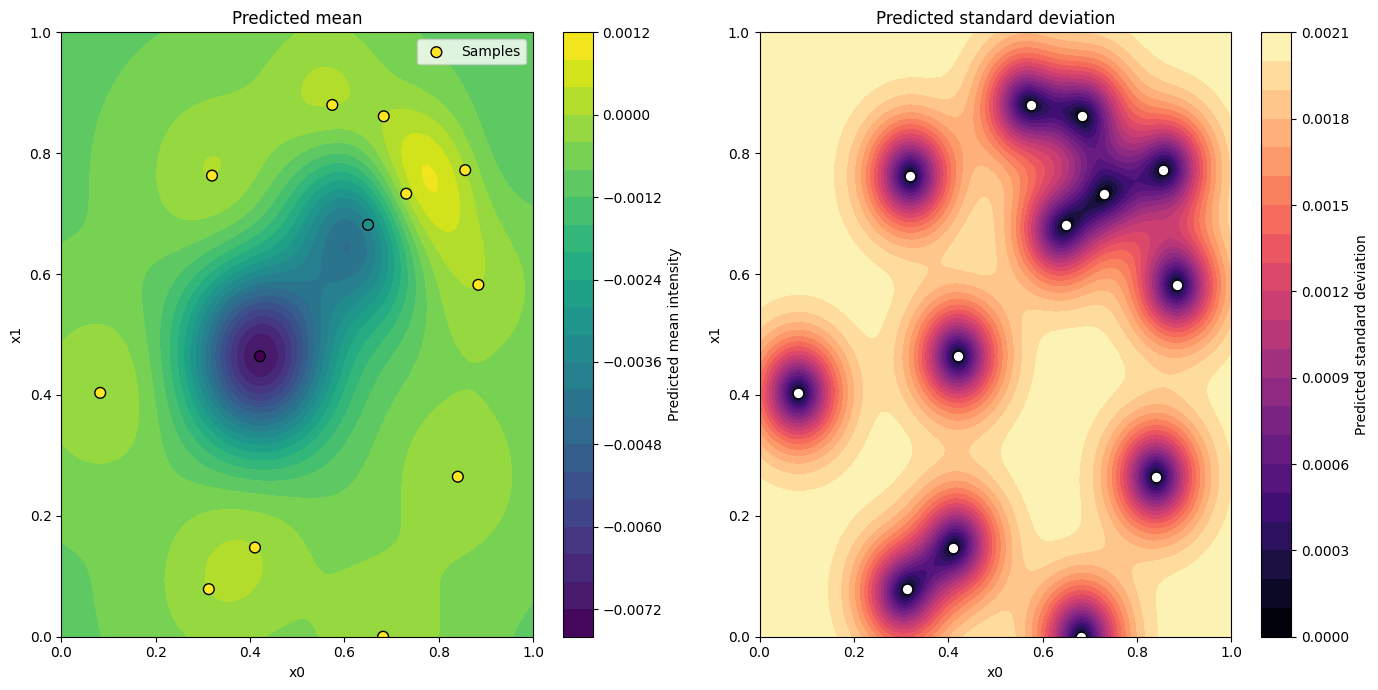

In [18]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

Although the promising area around (0.8, 0.8) has shrunk, it still looks promising.

In [19]:
# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.unravel_index(np.argmax(acquisition.ucb(Y_mean, Y_std, k=1.96)), Y_mean.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.4   0.925]


However, the UCB acquisition function suggests a different region to explore next. This is probably because of the relatively high value of the exploration parameter `k`. I am still not convinced that the largest observed value corresponds to a peak. Coupled with my opinion that there are enough queries left to allow for further exploration, the point proposed by the UCB acquisition function holds promise.

Before we continue down this path, I would like to explore whether a linear regression model could describe the underlying data.

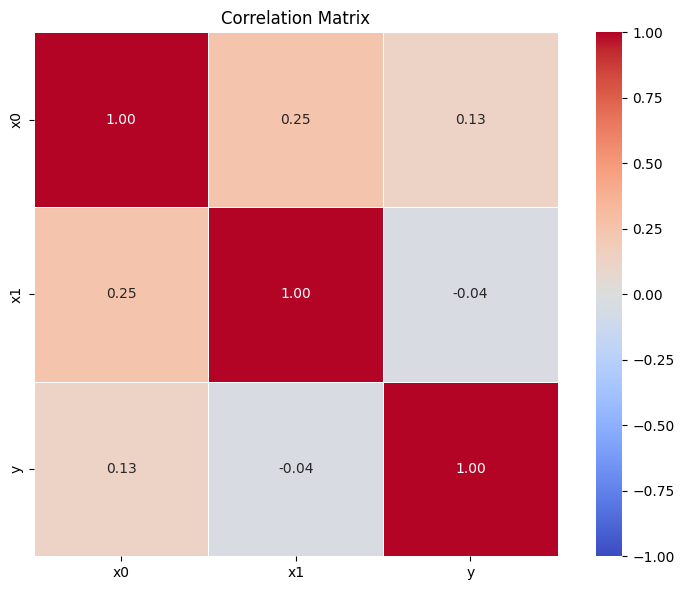

In [20]:
fig, ax = plot_correlation_matrix(X, y)

In [21]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "5-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=5),
}
for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")

Baseline RMSE = 0.002074256914460062

Leave One Out Cross Validation
linear model: RMSE = 0.002402876884556735, RMSE spread = 0.0016754334169124991, relative RMSE = 0.33347215407541536
quadratic model: RMSE = 0.0026536567059403907, RMSE spread = 0.0016145552207537325, relative RMSE = 0.3682754716207013
cubic model: RMSE = 0.003244353982608727, RMSE spread = 0.0022035640618444014, relative RMSE = 0.4502526609320086

5-Fold Cross Validation
linear model: RMSE = 0.002422954988315756, RMSE spread = 0.012819789905620166, relative RMSE = 0.33625860083567266
quadratic model: RMSE = 0.003354375007043472, RMSE spread = 0.010012485499752158, relative RMSE = 0.4655214199132272
cubic model: RMSE = 0.012383883669805236, RMSE spread = 0.03873715964638164, relative RMSE = 1.7186400142806835


There does not appear to be any clear correlation between any of the input features and the output, which would indicate that a linear fit would not be suitable.

We perform leave one out and 5-fold cross-validations, and compare the Root Mean Square Errors (RMSE). There are a couple of things to note. Firstly, none of the models within errors perform better than the baseline RMSE, which has been calculated using the mean as the predicted value for all observations. Secondly, the baseline RMSE is very large, because of the two very large negative values. We can mitigate this somewhat by using the Mean Square Error (MSE) instead:

In [22]:
print(f"Baseline MSE = {get_baseline_mse(y)}")

for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: MSE = {stats['MSE']}, MSE spread = {stats['MSE spread']}")

Baseline MSE = 0.0014074392506454698

Leave One Out Cross Validation
linear model: MSE = 5.773817322337081e-06, MSE spread = 1.258097372420713e-05
quadratic model: MSE = 7.041893912982404e-06, MSE spread = 8.482215732217871e-06
cubic model: MSE = 1.052583276446911e-05, MSE spread = 1.7080481801689493e-05

5-Fold Cross Validation
linear model: MSE = 5.870710875404203e-06, MSE spread = 7.905263672564044e-06
quadratic model: MSE = 1.1251831687877892e-05, MSE spread = 7.7493162172233e-06
cubic model: MSE = 0.00015336057474726878, MSE spread = 0.00024119351345659783


The MSE values across all models are lower than the baseline. However, there are some caveats: the outputs span several orders of magnitude, and the MSE is dominated by errors on the points of larger magnitude. These points are actually negative, and therefore the MSE values are potentially misleading.

The quadratic and cubic models have 6 and 10 parameters respectively. Given that there are only 14 data points, the number of parameters in the cubic model are comparable with the total data points, and therefore it may overfit the data. The quadratic model is perhaps borderline in this case.

While it may be useful to revisit linear regression in the future, at the moment, we should stick with the Gaussian Process surrogate model. We can perform a grid search to identify the point that yields the highest value for the UCB acquisition function, as we have done above. We can then zoom in on this point and perform another search, effectively at a higher resolution. We can repeat this until the we reach a resolution in the order of 1e-6, which is equivalent to the maximum number of decimal places that can be given to the inputs when submitting queries.

This is overkill in many respects, as the differences in outputs at these scales are likely to be negligible, and we do not have enough queries to explore to this accuracy. However, it does not result in any harm if we were going to select this point anyway, and is a useful exercise for future.

Better regions that warrant investigation can be masked by simply selecting the best point. While this is mitigated by using finer grid coordinates, this becomes harder at higher dimensions.

In [23]:
x_next = grid_search(model, acq_func=acquisition.ucb, k=1.96, n_dimensions=2, grd_res=grd_res)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.39983909 0.92483909]


## Week 5 - Investigating the influence of `x0`

In [24]:
import numpy as np

from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [25]:
X, y = get_current_weeks_points(function_id=1, week=5)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.399998 0.924758] yields -7.846998388820764e-98


Another negative output from last week's query, albeit very close to zero. So far we have assumed that both features contribute equally to the output, or in other words have the same length scales. However, this may not necessarily be the case, and one feature may contribute more than the other. We can fit the Gaussian Process surrogate model leaving the length scales in each dimension free to vary within limits.

Length scales: x0 = 999.9999999999998, x1 = 0.0339677651462081


/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


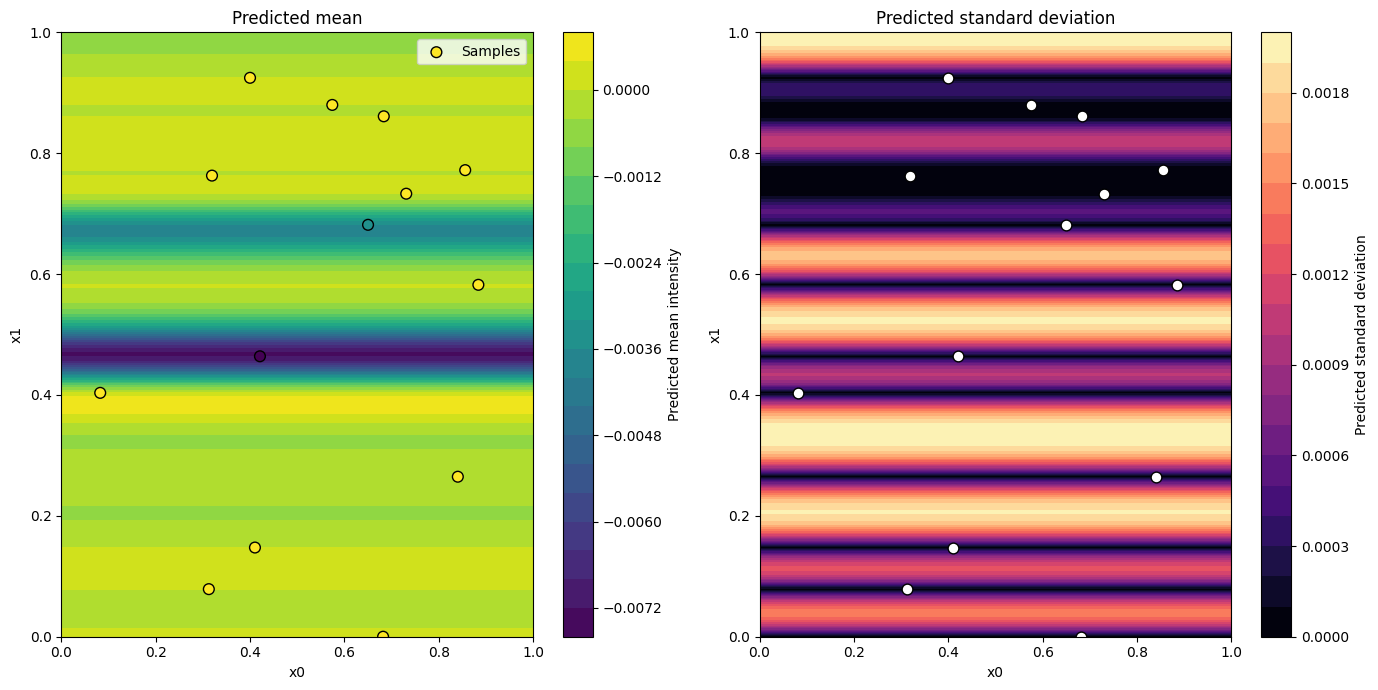

In [26]:
# Fit Gaussian Process surrogate model with RBF kernel on known data
# Length scales are initially set to 0.1 in both dimensions
model = get_reg_model(
    n_dimensions=2, seed_input=seed_input, length_scale_bounds=(1e-3, 1000)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

The length scale for `x0` reaches the upper bound, indicating that the model does not believe it to be important. Given that we have very few data points, we cannot reach the same conclusion with any certainty. However, we should test this. We can define a list of candidate points by fixing the `x1` coordinate from the best known point (i.e. the point that yields the highest output) and varying `x0`. The candidate where the model is most uncertain (i.e. the one with the highest standard deviation) should be queried:

In [27]:
# Take x1 of best known point and vary x0
x_best = X[np.argmax(y)]

x0_vals = np.linspace(0, 1, 1001)
x_test = np.tile(x_best, (1001, 1))
x_test[:, 0] = x0_vals

# Use standard deviation as acquisition function to find point where model is
# most uncertain
_, std = model.predict(x_test, return_std=True)
x_next = x_test[np.argmax(std)]

print(f"Proposed point to investigate sensitivity of x0 = {x_next}")

Proposed point to investigate sensitivity of x0 = [0.         0.73299988]


## Week 6 - Investigating noise

In [28]:
import numpy as np

from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [29]:
X, y = get_current_weeks_points(function_id=1, week=6)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.    0.733] yields -5.459525365620469e-192


The output is very close to zero. So close that the negative value is potentially meaningless. However, it would appear that `x0` is not irrelevant.

Length scales: x0 = 999.9999999999998, x1 = 0.033272842260211634


/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


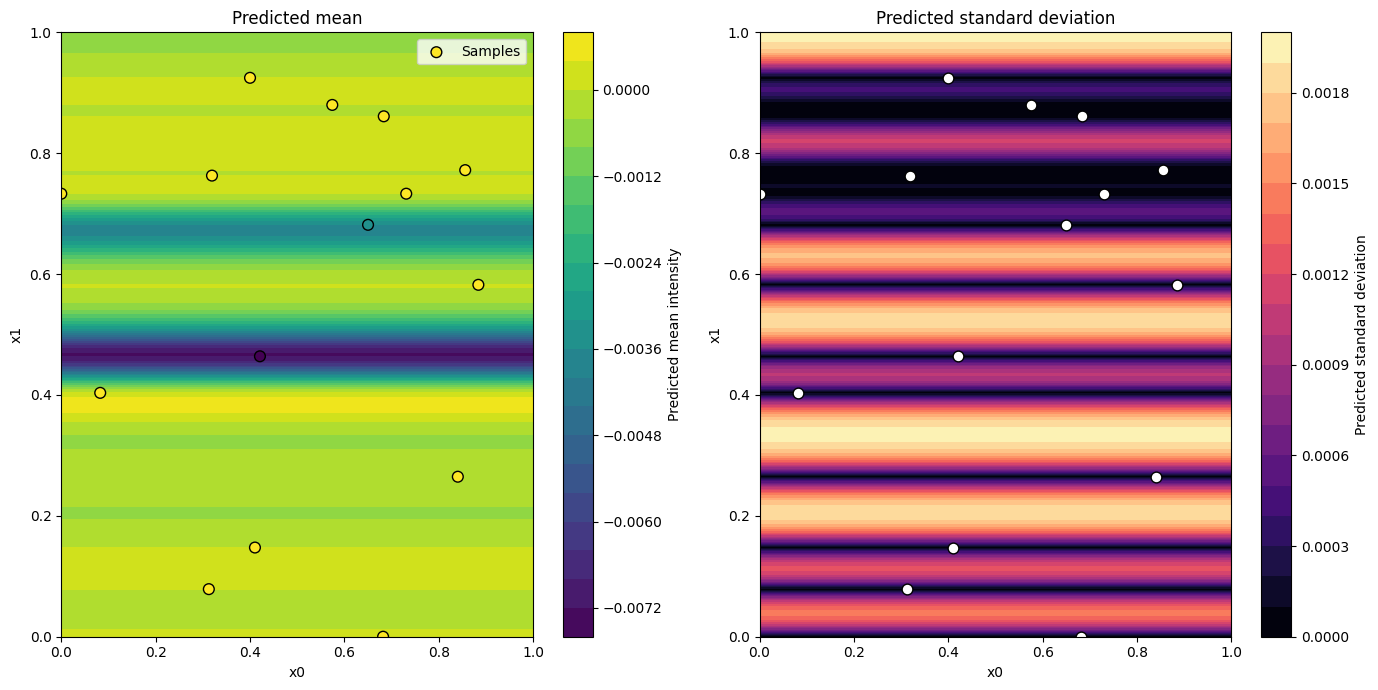

In [30]:
# Fit Gaussian Process surrogate model with RBF kernel on known data
# Length scales are initially set to 0.1 in both dimensions
model = get_reg_model(
    n_dimensions=2, seed_input=seed_input, length_scale_bounds=(1e-3, 1000)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

The large length scale in `x0` indicates that there is insufficient eveidence of variation rather than irrelevance.

Given the very low output values that we witness, we should try to establish the level of noise. We can do this by re-evaluating the best known point. If this query yields a value that is very close to the known output, it would indicate that the underlying function is deterministic and there may be little or no stochastic noise. A very different value would indicate the signal-to-noise ratio is very low. A value with a different order of magnitude would indicate a lot of instability, and optimisation may not be possible with so few queries.

In [31]:
x_next = X[np.argmax(y)]
print(f"Proposed point to investigate noise = {x_next}")

Proposed point to investigate noise = [0.73102363 0.73299988]


## Week 7 - Changing to a logarithmic scale

In [32]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_clf_model, get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import plot_2d_gp_acq_func_surface
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [33]:
X, y = get_current_weeks_points(function_id=1, week=7)

print(f"Last week's query {X[-1]} yields {y[-1]}")

max_idx = np.argmax(y)
print(f"Output of best point {X[max_idx]} is {y[max_idx]}")
print(f"Difference between last week's query and best point = {y[max_idx] - y[-1]}")

Last week's query [0.731024 0.733   ] yields 7.709397204501192e-16
Output of best point [0.73102363 0.73299988] is 7.710875114502849e-16
Difference between last week's query and best point = 1.477910001656961e-19


The difference between the output values of the current best observed point and last week's query is relatively small. It is around 3 orders of magnitude smaller than the output values, naively implying that the underlying function is likely to be deterministic. Having said that, the difference is still larger than the output values at other points, and it is possible that while the best point may lie above the noise, the other observed points lie within it.

As proposed in the first week, given the range of output values, it may be useful to use a logarithmic rather than linear scale. There are a few ways of dealing with negative values. We could ignore all negative values, but this would be a loss of information. Another option is to set all negative values to a very small positive value such as 1e-12.

While this option may have some merit, a better way of accomplishing this would be to fit two Gaussian Process surrogate models. The first would be a classification model, which would yield a probability that the output at a certain point would be positive. To facilitate this, observed points would be sorted into positive and negative groups according to their outputs. The second model would be a regression model which would only be fit on the logarithmic output values of the positive observed points. In this way, information about negative points is not lost and we are able to use a more appropriate scale.

We can also switch to using Matern kernels with smoothing parameters of 1.5 as the underlying function appears to be quite sharp.

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:193: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Proposed point from combined classification and regression GP surrogate models = [0.8844995 0.7594995]


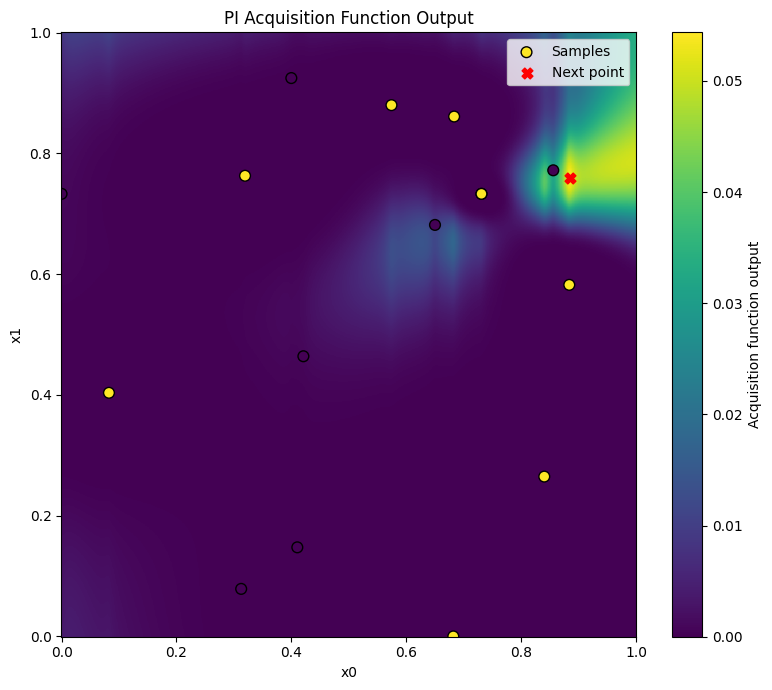

In [34]:
# Identify whether output of observed point is negative or positive and fit
# classification Gaussian Process model
sign_y = np.where(y > 0, 1, 0)
seed_input_clf = f"{seed_input} clf"
clf_model = get_clf_model(n_dimensions=n_dimensions, seed_input=seed_input_clf)
clf_model.fit(X, sign_y)

# Fit regression model with positive values in logarithmic scale
positive_x = X[y > 0]
positive_y = y[y > 0]
log_y = np.log(positive_y)
alpha = ((y[max_idx] - y[-1]) / y[max_idx]) ** 2
seed_input_reg = f"{seed_input} reg"
reg_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input_reg,
    kernel_type=KernelType.MATERN,
    alpha=alpha,
)
reg_model.fit(positive_x, log_y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])

# Get probability that grid point is positive from classification model
y_prob = clf_model.predict_proba(X_pred)
Y_prob = y_prob[:, 1].reshape(grd_res, grd_res)

# Get predicted mean and standard deviation from regressor model
y_mean, y_std = reg_model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Combine probability with Upper Confidence Bound (UCB) acquisition function
Y_acq = Y_prob * acquisition.prob_improv(Y_mean, Y_std, y[max_idx])

x_next = grid_search(
    model=reg_model,
    acq_func=acquisition.clf_prob_improv,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
    clf_model=clf_model,
    y_max=y[max_idx],
)

fig, axs = plot_2d_gp_acq_func_surface(
    X0=X0,
    X1=X1,
    Y_acq=Y_acq,
    x_samples=X,
    y_samples=sign_y,
    x_next=x_next,
    title="PI Acquisition Function Output",
)

print(f"Proposed point from combined classification and regression GP surrogate models = {x_next}")

I decided to use the product of the probability from the classification model and the probability of improvement from the regression model as the acquisition function. I decided to go with a more exploitative classification model because I wanted to be a bit braver and was interested to see what it would yield. The above plot shows some quite interesting features. It seems as though the upper right is a favoured region. The length scale for `x1` in the regression model hit the upper limit, implying that the model believes the underlying function to be smooth in this dimension. Therefore, the proposed point above should not come as any surprise as it lines up quite well with another positive point at around `x1` = 0.6.

Unfortunately, there is an error in the acquisition function above that was caught after the proposed point above had been submitted. While the mean and standard deviation are in logarithmic space, the maximum value of y is still in the original scale. This underestimates the probability of improvement as we are subtracting a number that is effectively zero from the mean. This should be fixed by converting it to logarithmic space.

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:193: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Corrected proposed point = [0.7325005 0.7325005]
Position of best observed point = [0.73102363 0.73299988]


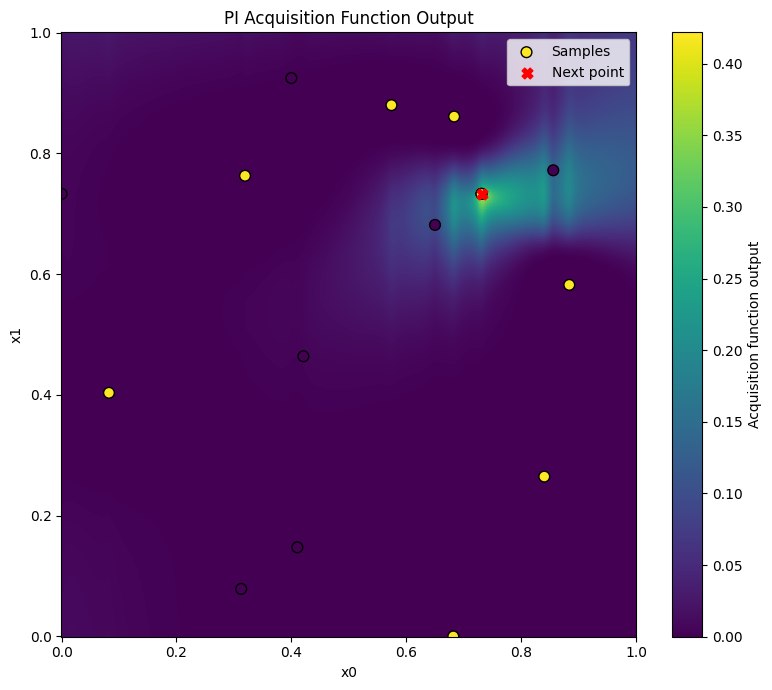

In [35]:
# Identify whether output of observed point is negative or positive and fit
# classification Gaussian Process model
sign_y = np.where(y > 0, 1, 0)
seed_input_clf = f"{seed_input} clf"
clf_model = get_clf_model(n_dimensions=n_dimensions, seed_input=seed_input_clf)
clf_model.fit(X, sign_y)

# Fit regression model with positive values in logarithmic scale
positive_x = X[y > 0]
positive_y = y[y > 0]
log_y = np.log(positive_y)
alpha = ((y[max_idx] - y[-1]) / y[max_idx]) ** 2
seed_input_reg = f"{seed_input} reg"
reg_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input_reg,
    kernel_type=KernelType.MATERN,
    alpha=alpha,
)
reg_model.fit(positive_x, log_y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])

# Get probability that grid point is positive from classification model
y_prob = clf_model.predict_proba(X_pred)
Y_prob = y_prob[:, 1].reshape(grd_res, grd_res)

# Get predicted mean and standard deviation from regressor model
y_mean, y_std = reg_model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Combine probability with Upper Confidence Bound (UCB) acquisition function
Y_acq = Y_prob * acquisition.prob_improv(Y_mean, Y_std, np.log(y[max_idx]))

x_next = grid_search(
    model=reg_model,
    acq_func=acquisition.clf_prob_improv,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
    clf_model=clf_model,
    y_max=np.log(y[max_idx]),
)

fig, axs = plot_2d_gp_acq_func_surface(
    X0=X0,
    X1=X1,
    Y_acq=Y_acq,
    x_samples=X,
    y_samples=sign_y,
    x_next=x_next,
    title="PI Acquisition Function Output",
)

print(f"Corrected proposed point = {x_next}")
print(f"Position of best observed point = {X[max_idx]}")

This result should not surprise us as the position of the proposed point lies very close to that of the best observed point. This is what we expect when using an exploitative acquisition function such as probability of improvement and a sharp landscape.

## Week 8 - A change in strategy

In [36]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_clf_model, get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import plot_2d_gp_acq_func_surface
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [37]:
X, y = get_current_weeks_points(function_id=1, week=8)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.884686 0.760315] yields -1.5900697175173932e-58


Given the error in last week's acquisition function, and the physical proximity of the queried point to a previously observed point with a negative value, it is not too surprising that the this week's output is negative.

We can investigate what a more exploratory Upper Confidence Bound (UCB) acquisition function would yield:

/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:193: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Proposed point from combined classification and regression GP surrogate models = [0.9994995 0.8094995]


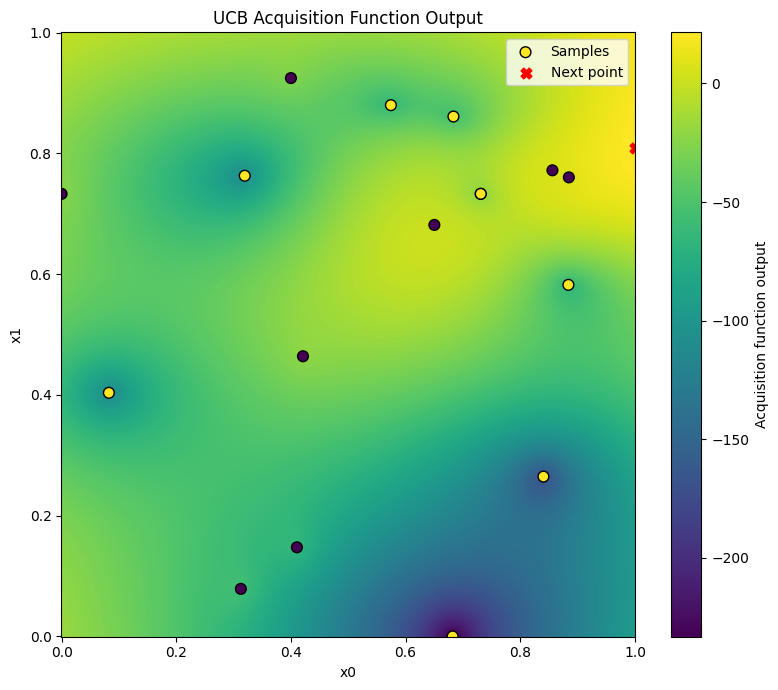

In [38]:
# Set noise as difference between top 2 points
top_2_idx = np.argsort(y)[-2:]
top_2_y = y[top_2_idx]
delta_y = np.abs(top_2_y[0] - top_2_y[1])
max_idx = top_2_idx[-1]

# Identify whether output of observed point is negative or positive and fit
# classification Gaussian Process model
sign_y = np.where(y > 0, 1, 0)
seed_input_clf = f"{seed_input} clf"
clf_model = get_clf_model(n_dimensions=n_dimensions, seed_input=seed_input_clf)
clf_model.fit(X, sign_y)

# Fit regression model with positive values in logarithmic scale
positive_x = X[y > 0]
positive_y = y[y > 0]
log_y = np.log(positive_y)
alpha = (delta_y / y[max_idx]) ** 2
seed_input_reg = f"{seed_input} reg"
reg_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input_reg,
    kernel_type=KernelType.MATERN,
    alpha=alpha,
)
reg_model.fit(positive_x, log_y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])

# Get probability that grid point is positive from classification model
y_prob = clf_model.predict_proba(X_pred)
Y_prob = y_prob[:, 1].reshape(grd_res, grd_res)

# Get predicted mean and standard deviation from regressor model
y_mean, y_std = reg_model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Combine probability with Upper Confidence Bound (UCB) acquisition function
Y_acq = Y_prob * acquisition.ucb(Y_mean, Y_std, k=1.96)

x_next = grid_search(
    model=reg_model,
    acq_func=acquisition.clf_ucb,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
    clf_model=clf_model,
    k=1.96,
)

fig, axs = plot_2d_gp_acq_func_surface(
    X0=X0,
    X1=X1,
    Y_acq=Y_acq,
    x_samples=X,
    y_samples=sign_y,
    x_next=x_next,
    title="UCB Acquisition Function Output",
)

print(f"Proposed point from combined classification and regression GP surrogate models = {x_next}")

The proposed point is very close to a boundary. There are other regions where the acquisition function output looks promising, and querying near a boundary may not be the best use of a limited evaluation budget.

So far, we have not identified a single point that has come to close to exceeding the output. It may be a good idea to use some of the remaining budget to focus on regions close to points that have yielded a positive output. If we look at the top 5 points:

In [39]:
# Give location of best 5 points
print("Best 5 points:")
top_5_idx = np.argsort(y)[:-6:-1]
for idx in top_5_idx:
    print(f"point = {X[idx]}: output = {y[idx]}")

Best 5 points:
point = [0.73102363 0.73299988]: output = 7.710875114502849e-16
point = [0.731024 0.733   ]: output = 7.709397204501192e-16
point = [0.68341817 0.86105746]: output = 2.5350011535584046e-40
point = [0.57432921 0.8798981 ]: output = 1.0330782375230975e-46
point = [0.88388983 0.58225397]: output = 6.229856468168659e-48


we see that the top 4 lie reasonably close to each other. The second highest point lies very close to the first point so can be excluded. We can submit the centroid of the remaining three points in a new query:

In [40]:
# Remember that the top two points lie very close to each other so let's only
# use one of them
top_3_idx = np.argsort(y)[:-5:-1]
top_3_idx = np.delete(top_3_idx, 1, axis=0)  # remove 2nd point
top_3_x = X[top_3_idx]
x_next = np.mean(top_3_x, axis=0)

print(f"Proposed point as centroid of top 3 points = {x_next}")

Proposed point as centroid of top 3 points = [0.66292367 0.82465182]


## Week 9 - A bit of success

In [41]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_clf_model, get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import plot_2d_gp_acq_func_surface
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [42]:
X, y = get_current_weeks_points(function_id=1, week=9)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.662924 0.824652] yields 1.0481965708189142e-30


Not bad at all. Although the latest point's output lies several orders of magnitude lower than that of the best point, it is the best result we have had so far. We can see how it changes the landscape.

However, before we do that, let's identify the indices for the top 2 points so we can use them in future to determine the noise:

In [43]:
# Display indices for best 2 points
top_2_idx = np.argsort(y)[-2:]
print(f"Indices for best 2 points: {top_2_idx}")

Indices for best 2 points: [15  2]


/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:193: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Proposed point from combined classification and regression GP surrogate models = [0.9994995 0.7994995]


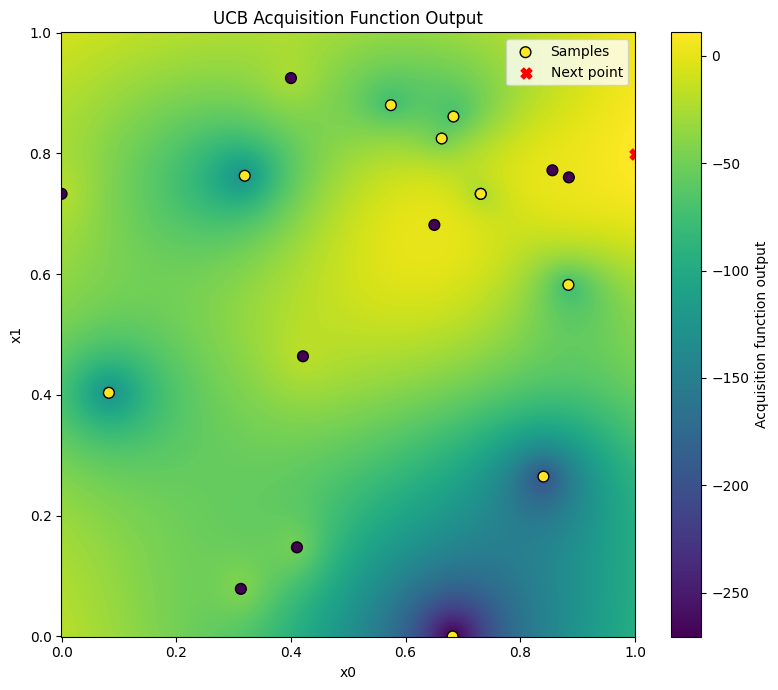

In [44]:
# Set noise as difference between top 2 points
top_2_y = y[top_2_idx]
delta_y = np.abs(top_2_y[0] - top_2_y[1])
max_idx = top_2_idx[-1]

# Identify whether output of observed point is negative or positive and fit
# classification Gaussian Process model
sign_y = np.where(y > 0, 1, 0)
seed_input_clf = f"{seed_input} clf"
clf_model = get_clf_model(n_dimensions=n_dimensions, seed_input=seed_input_clf)
clf_model.fit(X, sign_y)

# Fit regression model with positive values in logarithmic scale
positive_x = X[y > 0]
positive_y = y[y > 0]
log_y = np.log(positive_y)
alpha = (delta_y / y[max_idx]) ** 2
seed_input_reg = f"{seed_input} reg"
reg_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input_reg,
    kernel_type=KernelType.MATERN,
    alpha=alpha,
)
reg_model.fit(positive_x, log_y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])

# Get probability that grid point is positive from classification model
y_prob = clf_model.predict_proba(X_pred)
Y_prob = y_prob[:, 1].reshape(grd_res, grd_res)

# Get predicted mean and standard deviation from regressor model
y_mean, y_std = reg_model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Combine probability with Upper Confidence Bound (UCB) acquisition function
Y_acq = Y_prob * acquisition.ucb(Y_mean, Y_std, k=1.96)

x_next = grid_search(
    model=reg_model,
    acq_func=acquisition.clf_ucb,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
    clf_model=clf_model,
    k=1.96,
)

fig, axs = plot_2d_gp_acq_func_surface(
    X0=X0,
    X1=X1,
    Y_acq=Y_acq,
    x_samples=X,
    y_samples=sign_y,
    x_next=x_next,
    title="UCB Acquisition Function Output",
)

print(f"Proposed point from combined classification and regression GP surrogate models = {x_next}")

Again, the acquisition function suggests that the best point to query is one near the boundary.

As a new point has entered the top 3, we can find a new centroid to query:

In [45]:
top_3_idx = np.argsort(y)[:-5:-1]
top_3_idx = np.delete(top_3_idx, 1, axis=0)  # remove 2nd point
top_3_x = X[top_3_idx]
x_next = np.mean(top_3_x, axis=0)

print(f"Proposed point as centroid of top 3 points = {x_next}")

Proposed point as centroid of top 3 points = [0.69245527 0.80623645]


## Week 10 - A bit of a setback

In [46]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_clf_model, get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import plot_2d_gp_acq_func_surface, plot_2d_positive_negative
from bbo.utils import construct_meshgrid, get_circumference_points, grid_search

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution
noise_idx = [15, 2]  # indices of outputs for noise calculation

In [47]:
X, y = get_current_weeks_points(function_id=1, week=10)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.692455 0.806236] yields -1.879039862017659e-25


So, we end up with a negative value. This opens up the possibility of there being two peaks, and hence two promising regions to explore.

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:193: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Proposed point from combined classification and regression GP surrogate models = [0.9994995 0.8034995]


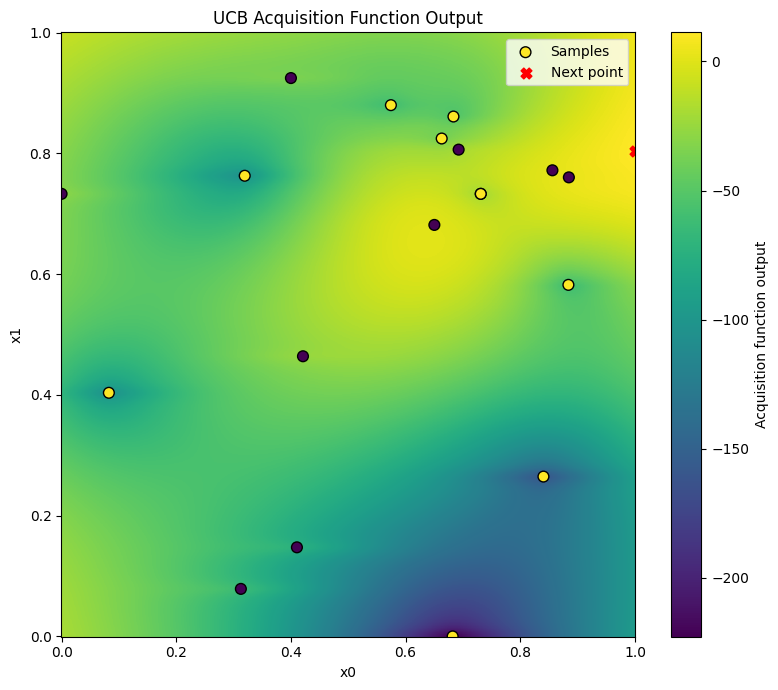

In [48]:
# Set noise
delta_y = np.abs(y[noise_idx[0]] - y[noise_idx[1]])
max_y = y[np.argmax(y)]

# Identify whether output of observed point is negative or positive and fit
# classification Gaussian Process model
sign_y = np.where(y > 0, 1, 0)
seed_input_clf = f"{seed_input} clf"
clf_model = get_clf_model(n_dimensions=n_dimensions, seed_input=seed_input_clf)
clf_model.fit(X, sign_y)

# Fit regression model with positive values in logarithmic scale
positive_x = X[y > 0]
positive_y = y[y > 0]
log_y = np.log(positive_y)
alpha = (delta_y / max_y) ** 2
seed_input_reg = f"{seed_input} reg"
reg_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input_reg,
    kernel_type=KernelType.MATERN,
    alpha=alpha,
)
reg_model.fit(positive_x, log_y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])

# Get probability that grid point is positive from classification model
y_prob = clf_model.predict_proba(X_pred)
Y_prob = y_prob[:, 1].reshape(grd_res, grd_res)

# Get predicted mean and standard deviation from regressor model
y_mean, y_std = reg_model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Combine probability with Upper Confidence Bound (UCB) acquisition function
Y_acq = Y_prob * acquisition.ucb(Y_mean, Y_std, k=1.96)

x_next = grid_search(
    model=reg_model,
    acq_func=acquisition.clf_ucb,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
    clf_model=clf_model,
    k=1.96,
)

fig, axs = plot_2d_gp_acq_func_surface(
    X0=X0,
    X1=X1,
    Y_acq=Y_acq,
    x_samples=X,
    y_samples=sign_y,
    x_next=x_next,
    title="UCB Acquisition Function Output",
)

print(f"Proposed point from combined classification and regression GP surrogate models = {x_next}")

Again, the Upper Confidence Bound (UCB) acquisition function with exploration parameter 1.96 suggests querying a point close to a boundary. We could reduce the exploration parameter. However, we would like to stay close to the best point, so could try a Probability of Improvement (PI) acquisition function:

/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:193: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Proposed point from combined classification and regression GP surrogate models = [0.7294995 0.7314995]


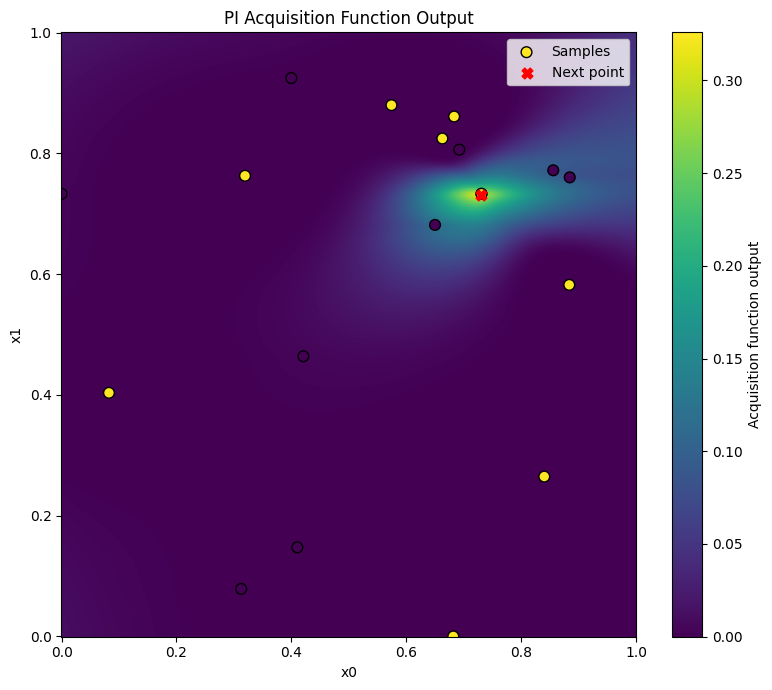

In [49]:
Y_acq = Y_prob * acquisition.prob_improv(Y_mean, Y_std, y_max=np.log(max_y))

x_next = grid_search(
    model=reg_model,
    acq_func=acquisition.clf_prob_improv,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
    clf_model=clf_model,
    y_max=np.log(max_y),
)

fig, axs = plot_2d_gp_acq_func_surface(
    X0=X0,
    X1=X1,
    Y_acq=Y_acq,
    x_samples=X,
    y_samples=sign_y,
    x_next=x_next,
    title="PI Acquisition Function Output",
)

print(f"Proposed point from combined classification and regression GP surrogate models = {x_next}")

The proposed point is too close to the best point to offer any meaningful insights.

Another possibility is to find the midpoint between the best observed point and the nearest negative point. We can define the distance from this midpoint to the best observed point as the radius of a circle of interest. We can then generate equidistant points that lie on the circumference of this circle, and find the point that maximises the acquisition function. In this way, we stay close to the best known point but not as close as the proposed point from the PI acquisition function.

Proposed point on circumference = [0.68968398 0.73105035]


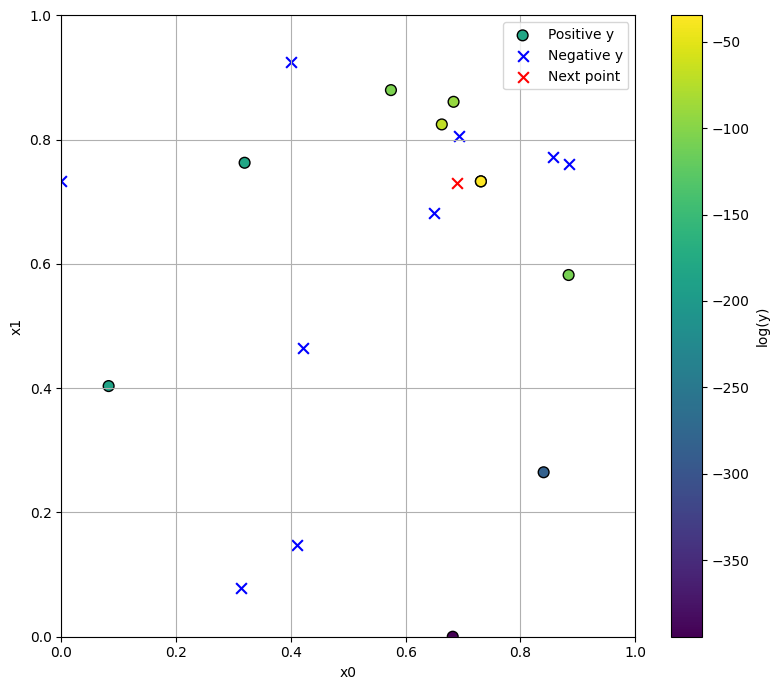

In [50]:
# Generate points on circumference
neg_x = X[y < 0]  # get points with negative output
x_candidates = get_circumference_points(x_best=X[np.argmax(y)], x_selection=neg_x)

y_prob = clf_model.predict_proba(x_candidates)[:, 1]
y_mean, y_std = reg_model.predict(x_candidates, return_std=True)

y_acq = y_prob * acquisition.prob_improv(y_mean, y_std, y_max=np.log(max_y))

max_candidate_idx = np.argmax(y_acq)
x_next = np.array(x_candidates[max_candidate_idx])
print(f"Proposed point on circumference = {x_next}")

fig, ax = plot_2d_positive_negative(
    pos_x=positive_x, pos_y=positive_y, neg_x=neg_x, x_next=x_next
)

Unfortunately, there was a mistake in my calculation of the noise and I did not pick up on this until after I had submitted the point (0.751979, 0.768688). However, this point is still lies on the circumference of the circle around the best observed point, so is also a valid candidate.

## Week 11 - Looking promising

In [51]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_clf_model, get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import plot_2d_positive_negative
from bbo.utils import get_circumference_points

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution
noise_idx = [15, 2]  # indices of outputs for noise calculation

In [52]:
X, y = get_current_weeks_points(function_id=1, week=11)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.751979 0.768688] yields 2.0199791483317315e-25


Our best query so far but still shy of the best point. Still, it appears as though this method has some merit. We can use the best observed point to find another candidate to query given the change in landscape.

Proposed point on circumference = [0.70185168 0.70364405]


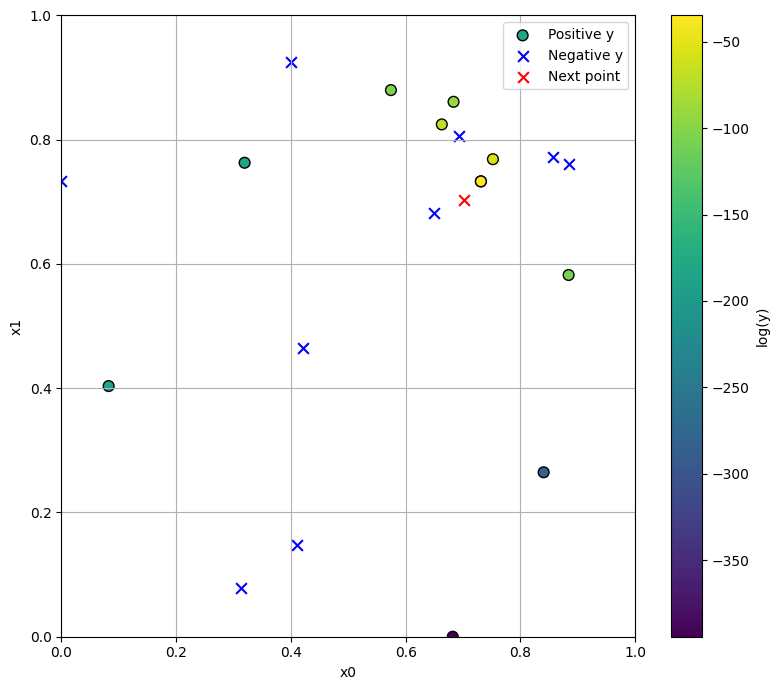

In [53]:
# Set noise
delta_y = np.abs(y[noise_idx[0]] - y[noise_idx[1]])
max_y = y[np.argmax(y)]

# Identify whether output of observed point is negative or positive and fit
# classification Gaussian Process model
sign_y = np.where(y > 0, 1, 0)
seed_input_clf = f"{seed_input} clf"
clf_model = get_clf_model(n_dimensions=n_dimensions, seed_input=seed_input_clf)
clf_model.fit(X, sign_y)

# Fit regression model with positive values in logarithmic scale
positive_x = X[y > 0]
positive_y = y[y > 0]
log_y = np.log(positive_y)
alpha = (delta_y / max_y) ** 2
seed_input_reg = f"{seed_input} reg"
reg_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input_reg,
    kernel_type=KernelType.MATERN,
    alpha=alpha,
)
reg_model.fit(positive_x, log_y)

# Generate points on circumference
neg_x = X[y < 0]  # get points with negative output
x_candidates = get_circumference_points(x_best=X[np.argmax(y)], x_selection=neg_x)

y_prob = clf_model.predict_proba(x_candidates)[:, 1]
y_mean, y_std = reg_model.predict(x_candidates, return_std=True)

y_acq = y_prob * acquisition.prob_improv(y_mean, y_std, y_max=np.log(max_y))

max_candidate_idx = np.argmax(y_acq)
x_next = np.array(x_candidates[max_candidate_idx])
print(f"Proposed point on circumference = {x_next}")

fig, ax = plot_2d_positive_negative(
    pos_x=positive_x, pos_y=positive_y, neg_x=neg_x, x_next=x_next
)

The mistake in the calculation of the noise permeated through to this week, and the point (0.690812, 0.723212) was submitted. This point lies relatively close to the proposed point above, so is likely to yield a similar output value.

## Week 12 - Breakthrough!

In [54]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_clf_model, get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import plot_2d_gp_acq_func_surface, plot_2d_positive_negative
from bbo.utils import construct_meshgrid, get_circumference_points, grid_search

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution
noise_idx = [15, 2]  # indices of outputs for noise calculation

In [55]:
X, y = get_current_weeks_points(function_id=1, week=12)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.690812 0.723212] yields 1.5193746282509825e-09


Finally we find a point with an output (several magnitudes) higher than the best point in the initial data set. It appears as though exploiting around the best point is yielding dividends. Now that there is a new best point, we can use the same method to find another point to query:

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 7 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://sciki

Proposed point on circumference = [0.66914447 0.70374351]


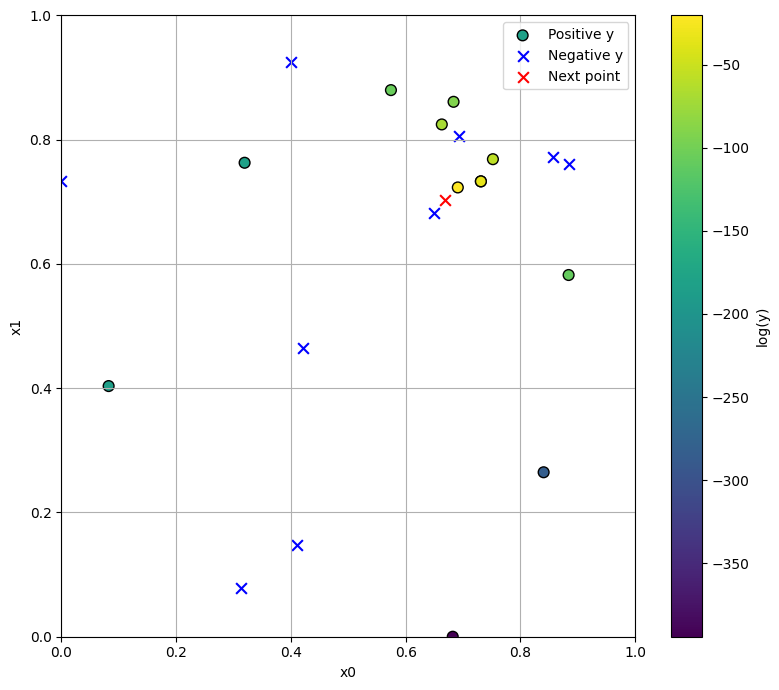

In [56]:
# Set noise
delta_y = np.abs(y[noise_idx[0]] - y[noise_idx[1]])
max_y = y[np.argmax(y)]

# Identify whether output of observed point is negative or positive and fit
# classification Gaussian Process model
sign_y = np.where(y > 0, 1, 0)
seed_input_clf = f"{seed_input} clf"
clf_model = get_clf_model(n_dimensions=n_dimensions, seed_input=seed_input_clf)
clf_model.fit(X, sign_y)

# Fit regression model with positive values in logarithmic scale
positive_x = X[y > 0]
positive_y = y[y > 0]
log_y = np.log(positive_y)
alpha = (delta_y / max_y) ** 2
seed_input_reg = f"{seed_input} reg"
reg_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input_reg,
    kernel_type=KernelType.MATERN,
    alpha=alpha,
)
reg_model.fit(positive_x, log_y)

# Generate points on circumference
neg_x = X[y < 0]  # get points with negative output
x_candidates = get_circumference_points(x_best=X[np.argmax(y)], x_selection=neg_x)

y_prob = clf_model.predict_proba(x_candidates)[:, 1]
y_mean, y_std = reg_model.predict(x_candidates, return_std=True)

y_acq = y_prob * acquisition.prob_improv(y_mean, y_std, y_max=np.log(max_y))

max_candidate_idx = np.argmax(y_acq)
x_next = np.array(x_candidates[max_candidate_idx])
print(f"Proposed point on circumference = {x_next}")

fig, ax = plot_2d_positive_negative(
    pos_x=positive_x, pos_y=positive_y, neg_x=neg_x, x_next=x_next
)

The nearest negative point to the best observed point has now changed. If we plot the Probability of Improvement (PI) acquisition function over the entire region, there is a favourable region between the best observed point and the nearest negative point:

/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:193: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Proposed point from combined classification and regression GP surrogate models = [0.6884995 0.7214995]


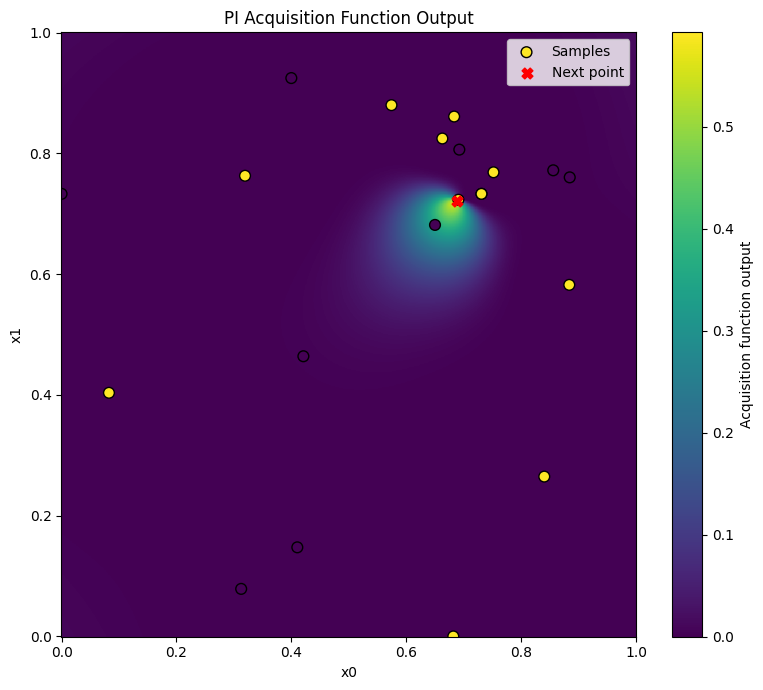

In [57]:
# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])

# Get probability that grid point is positive from classification model
y_prob = clf_model.predict_proba(X_pred)
Y_prob = y_prob[:, 1].reshape(grd_res, grd_res)

# Get predicted mean and standard deviation from regressor model
y_mean, y_std = reg_model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

Y_acq = Y_prob * acquisition.prob_improv(Y_mean, Y_std, y_max=np.log(max_y))

x_next = grid_search(
    model=reg_model,
    acq_func=acquisition.clf_prob_improv,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
    clf_model=clf_model,
    y_max=np.log(max_y),
)

fig, axs = plot_2d_gp_acq_func_surface(
    X0=X0,
    X1=X1,
    Y_acq=Y_acq,
    x_samples=X,
    y_samples=sign_y,
    x_next=x_next,
    title="PI Acquisition Function Output",
)

print(f"Proposed point from combined classification and regression GP surrogate models = {x_next}")

However, there was a mistake in my analysis that produced a rather interesting PI acquisition function plot that identified another promising area a little farther away at (0.726, 0.625). I decided to query this point, which in hindsight may have been a poor decision because only two queries were left and I burnt one of them in a new region when there was a promising candidate near the best observed point.

## Week 13 - A wasted query

In [58]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_clf_model, get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import plot_2d_positive_negative
from bbo.utils import get_circumference_points

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution
noise_idx = [15, 2]

In [59]:
X, y = get_current_weeks_points(function_id=1, week=13)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.726 0.625] yields -3.5422587900122714e-07


Unfortunately, my mistake last week means that this query was wasted. This result will have made very little difference to the landscape. With my last query, I should find the maximum Probability of Improvement (PI) in a list of candidate points that lie along the circumference of a circle with a radius equal to the midpoint between the best observed point and its nearest negative point:

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 7 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Proposed point on circumference = [0.66498358 0.70974365]


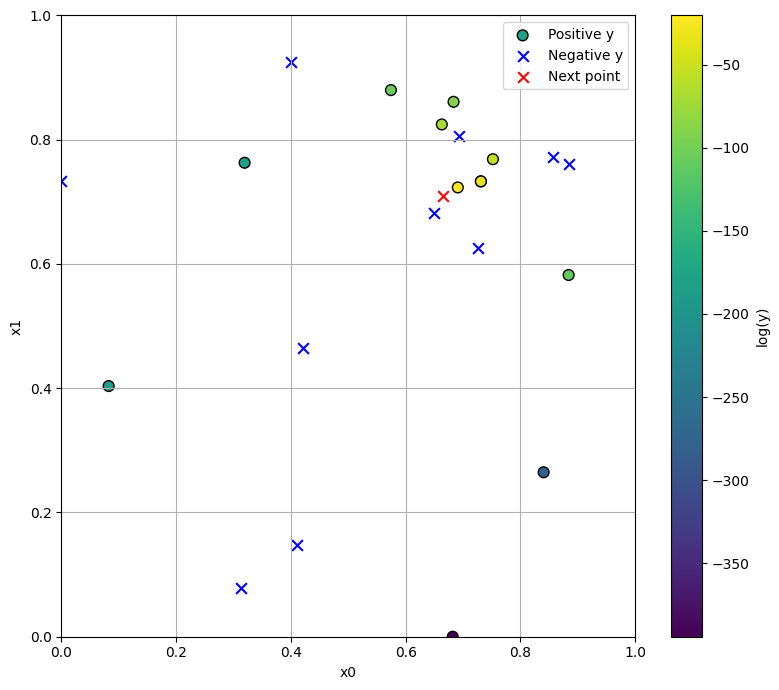

In [60]:
# Set noise
delta_y = np.abs(y[noise_idx[0]] - y[noise_idx[1]])
max_y = y[np.argmax(y)]

# Identify whether output of observed point is negative or positive and fit
# classification Gaussian Process model
sign_y = np.where(y > 0, 1, 0)
seed_input_clf = f"{seed_input} clf"
clf_model = get_clf_model(n_dimensions=n_dimensions, seed_input=seed_input_clf)
clf_model.fit(X, sign_y)

# Fit regression model with positive values in logarithmic scale
positive_x = X[y > 0]
positive_y = y[y > 0]
log_y = np.log(positive_y)
alpha = (delta_y / max_y) ** 2
seed_input_reg = f"{seed_input} reg"
reg_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input_reg,
    kernel_type=KernelType.MATERN,
    alpha=alpha,
)
reg_model.fit(positive_x, log_y)

# Generate points on circumference
neg_x = X[y < 0]  # get points with negative output
x_candidates = get_circumference_points(x_best=X[np.argmax(y)], x_selection=neg_x)

y_prob = clf_model.predict_proba(x_candidates)[:, 1]
y_mean, y_std = reg_model.predict(x_candidates, return_std=True)

y_acq = y_prob * acquisition.prob_improv(y_mean, y_std, y_max=np.log(max_y))

max_candidate_idx = np.argmax(y_acq)
x_next = np.array(x_candidates[max_candidate_idx])
print(f"Proposed point on circumference = {x_next}")

fig, ax = plot_2d_positive_negative(
    pos_x=positive_x, pos_y=positive_y, neg_x=neg_x, x_next=x_next
)

## Final Result

In [61]:
from bbo.data import get_current_weeks_points

X, y = get_current_weeks_points(function_id=1, week=14)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.664984 0.709744] yields -7.012084541033687e-07


The output from the final week's query is a bit disappointing, but indicates that the landscape is very jagged. The final plot is shown below:

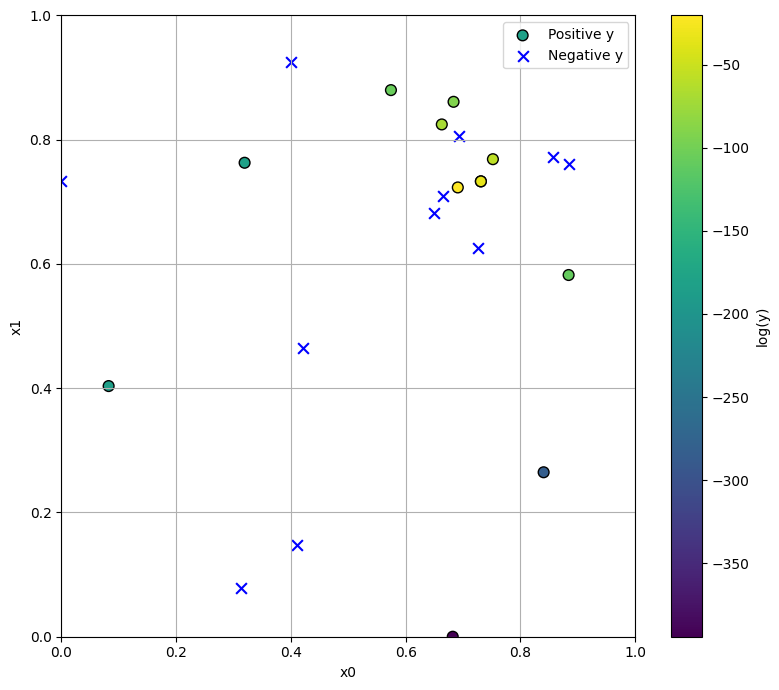

In [62]:
# Points with positive output
positive_x = X[y > 0]
positive_y = y[y > 0]

neg_x = X[y < 0]  # points with negative output

fig, ax = plot_2d_positive_negative(
    pos_x=positive_x, pos_y=positive_y, neg_x=neg_x
)

While the latest point has a disappointing output, the method of a combining global Gaussian Process classification and regression models, and evaluating candidates that lie on the circumference of a circle around the best point with radius equal to the midpoint between the best point and nearest negative point has been the most successful. It is the only method that found a point with output greater than that of the initial data.

It is clear that the underlying function is rough with at least two local maxima. If I had more queries, I would continue to investigate the region around the current best point in a similar fashion, and then move on to the next promising region at approximately (0.65, 0.83).